In [1]:
import kagglehub
import shutil
import os
import polars as pl
from google.colab import drive
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
sns.set_context("talk")
sns.set_style("ticks")

### **!Note!**: this dataset is artificially generated. While it serves to illustrate polynomial regression techniques, the specific values may not reflect actual real-world scenarios

In [2]:
drive.mount('/content/drive')

target_dir = '/content/drive/MyDrive/datasets'
os.makedirs(target_dir, exist_ok=True)
temp_path = kagglehub.dataset_download("mirajdeepbhandari/polynomial-regression")

for filename in os.listdir(temp_path):
    source_file = os.path.join(temp_path, filename)
    destination_file = os.path.join(target_dir, filename)

    shutil.copy2(source_file, destination_file)
    print(f"Saved: {destination_file}")

file_path = os.path.join(target_dir, "Ice_cream selling data.csv")
df = pl.read_csv(file_path)
df = df.rename({
    "Temperature (°C)": "Temperature",
    "Ice Cream Sales (units)": "Nr_of_icecream_sold"
}).with_columns(
    pl.col("Nr_of_icecream_sold").cast(pl.Int64)
)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'polynomial-regression' dataset.
Saved: /content/drive/MyDrive/datasets/Ice_cream selling data.csv
shape: (5, 2)
┌─────────────┬─────────────────────┐
│ Temperature ┆ Nr_of_icecream_sold │
│ ---         ┆ ---                 │
│ f64         ┆ i64                 │
╞═════════════╪═════════════════════╡
│ -4.662263   ┆ 41                  │
│ -4.316559   ┆ 34                  │
│ -4.213985   ┆ 39                  │
│ -3.949661   ┆ 37                  │
│ -3.578554   ┆ 32                  │
└─────────────┴─────────────────────┘


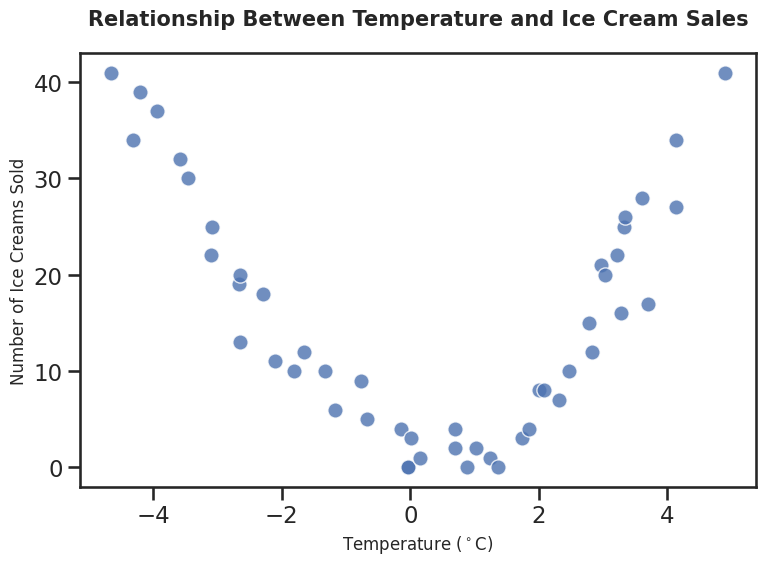

In [3]:
plt.figure(figsize=(8, 6))

scatter = sns.scatterplot(
    data=df.to_pandas(),
    x="Temperature",
    y="Nr_of_icecream_sold",
    color="#4C72B0",
    edgecolor="w",
    linewidth=1,
    s=120,
    alpha=0.8
)

plt.title("Relationship Between Temperature and Ice Cream Sales", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(r"Temperature ($^\circ$C)", fontsize=12)
plt.ylabel("Number of Ice Creams Sold", fontsize=12)

plt.tight_layout()
plt.show()

The scatter plot reveals a clear non-linear relationship between `Temperature` and `Ice Cream Sales`. Based on the distribution of the data points, we can draw the following conclusions:

> Parabolic Trend: The data exhibits a distinct "U-shape" (parabolic trend) rather than a straight line. This suggests that sales decrease as the temperature approaches approximately 0∘C from both the negative and positive directions, then rise sharply as temperatures become more extreme.

In [4]:
X = df.select("Temperature").to_pandas()
y = df.select("Nr_of_icecream_sold").to_pandas().values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(f"Polynomial R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Polynomial R2 Score: 0.8643179997204904
Mean Squared Error: 14.412800408389094


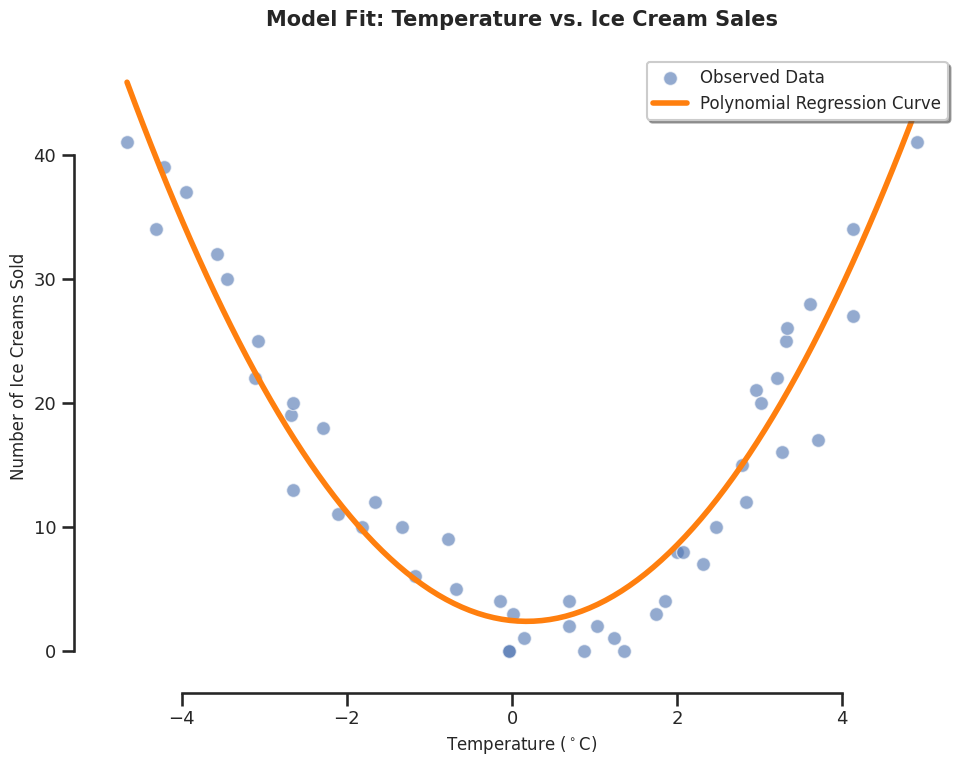

In [5]:
raw_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range = pd.DataFrame(raw_range, columns=["Temperature"])
y_range_pred = pipeline.predict(X_range)


plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=df.to_pandas(),
    x="Temperature",
    y="Nr_of_icecream_sold",
    color="#4C72B0",
    edgecolor="w",
    linewidth=1,
    s=100,
    alpha=0.6,
    label="Observed Data"
)

plt.plot(
    X_range,
    y_range_pred,
    color="#FF7F0E",
    linewidth=4,
    label="Polynomial Regression Curve"
)

plt.title("Model Fit: Temperature vs. Ice Cream Sales", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(r"Temperature ($^\circ$C)", fontsize=12)
plt.ylabel("Number of Ice Creams Sold", fontsize=12)

sns.despine(offset=10, trim=True)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

Based on the visualization and numerical metrics, we can draw the following conclusions:

- Strong Predictive Power (R^2≈0.86): A Coefficient of Determination of 0.86 is remarkably strong for such a small dataset. It indicates that 86% of the variability in ice cream sales can be directly explained by the measured temperature. The remaining 14% variability is likely due to other unmeasured factors (e.g., time of day, day of the week, or location).

- Low Residual Error (MSE ≈14.4): While an MSE of 14.4 might sound high, its square root (RMSE ≈3.8) tells us that on average, the model's predictions differ from the actual sales by only about 4 units.

**Final Verdict:** The second-degree Polynomial Regression model is highly effective and appropriate for predicting ice cream sales based on temperature. The visualization validates that the model is neither underfitting (too simple) nor significantly overfitting (learning random noise).